# Vision-Language

## VLP
VLP emerged as a key area in multimodal AI, aiming to bridge visual and textual data through deep learning. It leverages large-scale datasets (e.g., COCO, Conceptual Captions) and transformer-based architectures to learn joint representations, enabling tasks like image-text retrieval, visual question answering (VQA), and caption generation.
BLIP is a specific implementation of the VLP framework, distinguished by its bootstrapping data cleaning and unified architecture for understanding/generation tasks. It addresses key limitations in earlier VLP models (e.g., CLIP’s lack of generation capability).

**BLIP is a two-stage framework:**

- Noisy Data Bootstrapping: Filter low-quality web-collected image-text pairs.
    - Train a captioner model to generate synthetic captions for web images.
    - Use a filter model to remove mismatched (image, text) pairs.
    - Combine cleaned web data + synthetic captions → final training corpus.

- Multimodal Pretraining: Jointly train vision and language models on cleaned data.
    - Align **i**mage and **t**ext embeddings via **c**ontrastive loss.(ITC)
    - Binary classification to predict if (**i**mage, **t**ext) pairs **m**atch.(ITM)
    - Generate captions autoregressively (cross-entropy loss).(language model,LM)

In [ ]:
# $bash
pip install torch torchvision transformers Pillow

If the installation is fail, check the compatibility issues with versions.

In [9]:
import os
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import requests

Only new version `transformers` lib(>= v4.17.0) support `BlipProcessor` and `BlipForConditionalGeneration`

In [13]:
# 加载BLIP的处理器和模型（预训练权重）
model_path = "./blip-image-captioning-base"  # 替换为你的实际路径
processor = BlipProcessor.from_pretrained(model_path)
model = BlipForConditionalGeneration.from_pretrained(model_path)

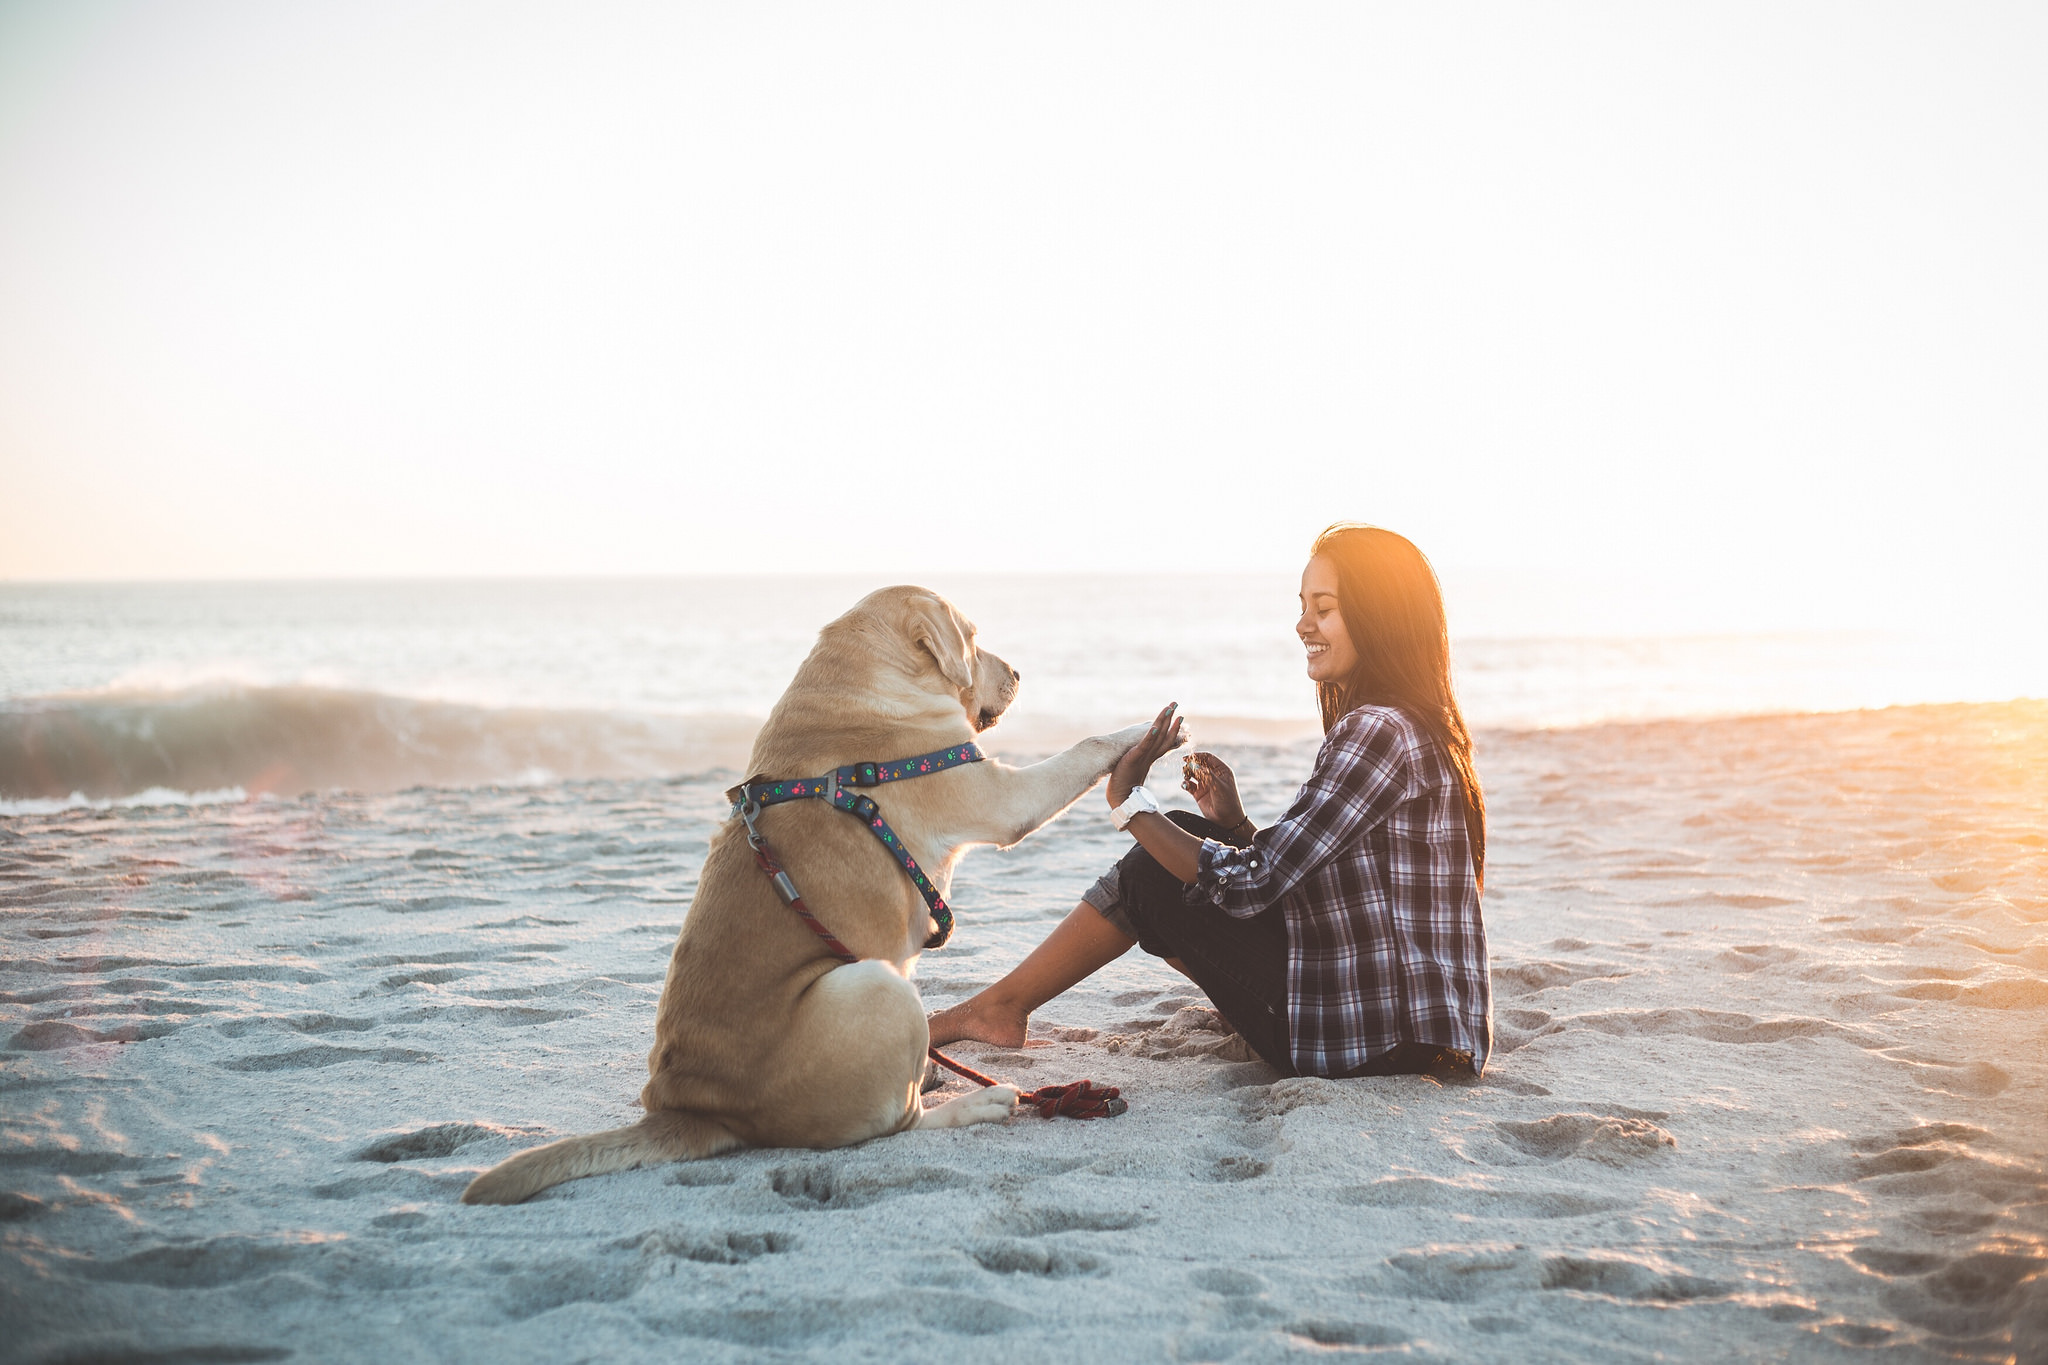

Generated Caption: a woman sitting on the beach with her dog


In [15]:
# 加载图像（本地文件或URL）
image_url = "https://storage.googleapis.com/sfr-vision-language-research/BLIP/demo.jpg"
image = Image.open(requests.get(image_url, stream=True).raw).convert("RGB")
display(image)


# 预处理图像+文本（可选输入提示）
inputs = processor(image, return_tensors="pt")  # 不提供文本时，模型自动生成描述

# 生成描述（贪婪解码）
outputs = model.generate(**inputs, max_length=50)
caption = processor.decode(outputs[0], skip_special_tokens=True)

print("Generated Caption:", caption)

## Clip
CLIP is a vision-language model developed by OpenAI in 2021, designed to learn visual concepts from natural language descriptions through contrastive learning.It aligns images and text in a shared embedding space, enabling zero-shot transfer to downstream tasks.

**Contrastive Learning**: CLIP trains by maximizing similarity between correct image-text pairs and minimizing it for incorrect pairs.

**Multimodal Embeddings**: Images and texts are mapped to a joint space where semantically similar pairs are close.


There are steps:

**Data Collection**:Trained on 400M+ image-text pairs from the internet (e.g., WIT dataset).

**Loss Function**:Contrastive loss (InfoNCE) over batch-wise cosine similarities.

**Optimization**:Large-scale distributed training with Adam optimizer.

In [ ]:
# $bash
conda install --yes -c pytorch pytorch=1.7.1 torchvision cudatoolkit=11.0
pip install ftfy regex tqdm
pip install git+https://github.com/openai/CLIP.git

Replace `cudatoolkit=11.0` above with the appropriate CUDA version on your machine or `cpuonly` when installing on a machine without a GPU.

In [1]:
import torch
import clip
from PIL import Image
import requests
from io import BytesIO

C:\ProgramData\Anaconda3\lib\site-packages\torch\cuda\__init__.py:52: UserWarning: CUDA initialization: Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx (Triggered internally at  ..\c10\cuda\CUDAFunctions.cpp:100.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
# 检查CLIP版本是否正确
#print("CLIP版本:", clip.__version__)  # 应显示如 1.0

# 初始化模型（使用CPU）
device = "cpu"
model, preprocess = clip.load("RN50", device=device, download_root="./models")  # 下载模型到本地./models目录

100%|███████████████████████████████████████| 244M/244M [00:16<00:00, 15.8MiB/s]


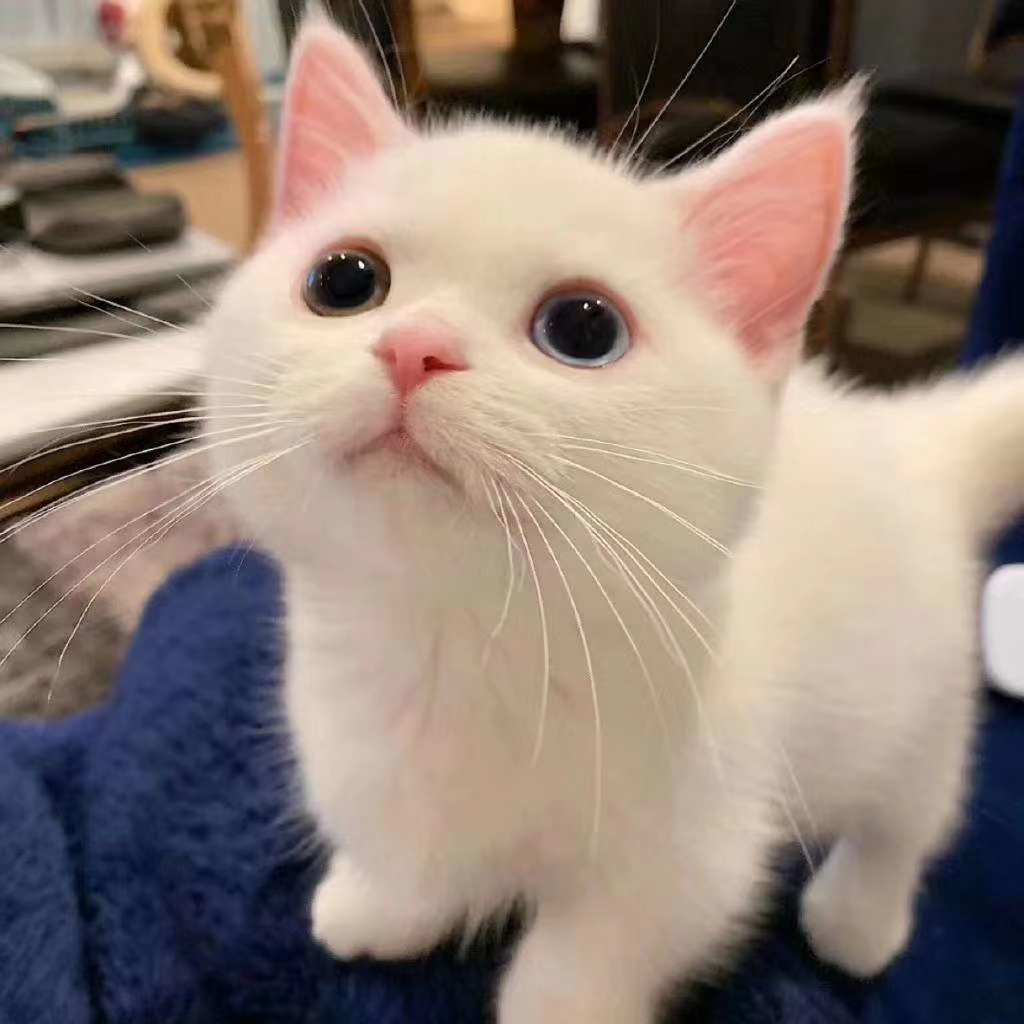

In [6]:
# 示例图像
try:
    image = Image.open("cat.jpg")
    display(image)
    image_input = preprocess(image).unsqueeze(0).to(device)
except Exception as e:
    print("图像加载失败:", e)
    # 改用本地备用图片
    image = Image.new("RGB", (224, 224), color="red")  # 创建红色占位图
    image_input = preprocess(image).unsqueeze(0).to(device)

# 文本输入
text_inputs = ["a photo of a cat", "a photo of a dog", "a red image"]
text_tokens = clip.tokenize(text_inputs).to(device)

In [9]:
# 推理
with torch.no_grad():
    image_features = model.encode_image(image_input)
    text_features = model.encode_text(text_tokens)
    similarity = (image_features @ text_features.T).softmax(dim=-1)

# 打印结果
print("\n匹配概率:")
for text, prob in zip(text_inputs, similarity[0]):
    print(f"- '{text}': {prob.item()*100:.1f}%")

# 如果是红色占位图，会显示警告
#if "red" in image.lower():
#    print("\n警告: 使用了红色占位图，请替换为真实图片URL或本地路径")


匹配概率:
- 'a photo of a cat': 73.6%
- 'a photo of a dog': 16.1%
- 'a red image': 10.3%
